In [37]:
!pip install selenium
!pip install undetected-chromedriver
!apt-get update
!apt-get install -y xvfb
!pip install flask

'apt-get' is not recognized as an internal or external command,
operable program or batch file.
'apt-get' is not recognized as an internal or external command,
operable program or batch file.


  Using cached itsdangerous-2.2.0-py3-none-any.whl.metadata (1.9 kB)
Using cached itsdangerous-2.2.0-py3-none-any.whl (16 kB)


In [39]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
import flask 
import os

os.environ["DISPLAY"] = ":0"

options = Options()
options.add_argument("--headless")

# Set the path to the manually downloaded ChromeDriver
chromedriver_path = "C:/Users/Albert/Documents/University/Work/Marketing/chromedriver.exe"

driver = webdriver.Chrome(service=Service(chromedriver_path), options=options)

In [20]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
import time
import undetected_chromedriver as uc
from IPython.display import display, Image

# Set Instagram credentials
IG_EMAIL = "97idk97"
IG_PASSWORD = "97524Idk1"

# Set the Instagram post URL
POST_URL = "https://www.instagram.com/p/DFtmvfLs6vY/"
TARGET_USERNAME = "gabe10s"

✅ Login successful!


ProtocolError: ('Connection aborted.', ConnectionResetError(10054, 'An existing connection was forcibly closed by the remote host', None, 10054, None))

In [ ]:
#DO NOT RUN!!!

import os
import time
import undetected_chromedriver as uc
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC

app = Flask(__name__, template_folder="templates")

@app.route('/')
def index():
    return render_template('index.html')

@app.route('/instagram', methods=['POST'])
def instagram_scrape():
    ig_email = request.form.get("ig_email")
    ig_password = request.form.get("ig_password")
    post_url = request.form.get("post_url")
    target_usernames_str = request.form.get("target_usernames")
    
    target_list = [username.strip().lower() for username in target_usernames_str.split(",") if username.strip()]
    found_usernames = {username: False for username in target_list}
    screenshot_paths = {}

    options = uc.ChromeOptions()
    options.add_argument("--disable-blink-features=AutomationControlled")
    
    driver = uc.Chrome(options=options, headless=False)

    driver.get("https://www.instagram.com/accounts/login/")
    time.sleep(5)
    try:
        wait = WebDriverWait(driver, 10)
        email_input = wait.until(EC.presence_of_element_located((By.NAME, "username")))
        email_input.send_keys(ig_email)
        password_input = driver.find_element(By.NAME, "password")
        password_input.send_keys(ig_password)
        password_input.send_keys(Keys.ENTER)
        time.sleep(5)
        try:
            not_now_button = wait.until(EC.presence_of_element_located((By.XPATH, "//button[text()='Not Now']")))
            not_now_button.click()
            time.sleep(3)
        except Exception:
            pass
    except Exception as e:
        driver.quit()
        return f"Login failed: {e}"

    driver.get(post_url)
    time.sleep(5)

    try:
        comment_section = WebDriverWait(driver, 10).until(
            EC.presence_of_element_located((By.XPATH, "//*[@id='mount_0_0_r+']/div/div/div[2]/div/div/div[1]/div[1]/div[1]/section/main/div/div[1]/div/div[2]/div/div[2]/div/div[2]"))
        )
        driver.execute_script("arguments[0].scrollIntoView();", comment_section)
        time.sleep(3)
    except Exception as e:
        print("Could not lock tab to comment section:", e)

    static_folder = os.path.join(os.getcwd(), "static")
    os.makedirs(static_folder, exist_ok=True)

    def get_focused_element():
        return driver.execute_script("return document.activeElement;")

    tab_count = 0
    safety_limit = 500
    while not all(found_usernames.values()) and tab_count < safety_limit:
        driver.find_element(By.TAG_NAME, "body").send_keys(Keys.TAB)
        time.sleep(0.1)
        tab_count += 1
        focused_element = get_focused_element()
        if focused_element:
            highlighted_text = focused_element.text.strip().lower()
            print(f"🔍 Highlighted: {highlighted_text}")
            for username in target_list:
                if not found_usernames[username] and username in highlighted_text:
                    print(f"✅ Found '{username}'!")
                    found_usernames[username] = True

                    # Press one more tab after finding the username
                    driver.find_element(By.TAG_NAME, "body").send_keys(Keys.TAB)
                    time.sleep(0.1)
                    tab_count += 1

                    # Press one more tab before taking the screenshot
                    driver.find_element(By.TAG_NAME, "body").send_keys(Keys.TAB)
                    time.sleep(0.1)
                    tab_count += 1

                    # Save a screenshot specific to this username
                    screenshot_filename = f"instagram_screenshot_{username}.png"
                    screenshot_path = os.path.join(static_folder, screenshot_filename)
                    driver.save_screenshot(screenshot_path)
                    screenshot_paths[username] = "/static/" + screenshot_filename

        try:
            load_more = driver.find_element(By.XPATH, "//svg[@aria-label='Load more comments']")
            driver.execute_script("arguments[0].click();", load_more)
            print("🔄 Clicked 'Load more comments'")
            time.sleep(2)
        except Exception:
            pass

    if tab_count >= safety_limit:
        print("⚠️ Safety limit reached. Not all usernames may have been found.")

    # Press one more tab before quitting
    driver.find_element(By.TAG_NAME, "body").send_keys(Keys.TAB)
    time.sleep(0.1)

    driver.quit()

    return render_template("result.html", screenshot_paths=screenshot_paths, 
                           found_usernames=found_usernames, mode="instagram")

if __name__ == '__main__':
    import threading, webbrowser
    def open_browser():
        webbrowser.open("http://127.0.0.1:5000")
    threading.Timer(1, open_browser).start()
    
    app.run(debug=True)


In [15]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
import time
import undetected_chromedriver as uc
from IPython.display import display, Image

# Set Instagram credentials
IG_EMAIL = "email/username"
IG_PASSWORD = "password"

# Set the Instagram post URL and target username
POST_URL = "INPUT URL"
TARGET_USERNAME = "INPUT TARGET"

# Start undetectable Chrome
options = webdriver.ChromeOptions()
options.add_argument("--disable-blink-features=AutomationControlled")  # Avoid detection
driver = uc.Chrome(options=options, headless=False)

# Open Instagram login page
driver.get("https://www.instagram.com/accounts/login/")
time.sleep(5)

# Function to log in
def login_instagram():
    try:
        wait = WebDriverWait(driver, 10)

        # Enter email
        email_input = wait.until(EC.presence_of_element_located((By.NAME, "username")))
        email_input.send_keys(IG_EMAIL)

        # Enter password
        password_input = driver.find_element(By.NAME, "password")
        password_input.send_keys(IG_PASSWORD)
        password_input.send_keys(Keys.ENTER)
        time.sleep(5)

        # Handle "Save Login Info" popup (optional)
        try:
            not_now_button = wait.until(EC.presence_of_element_located((By.XPATH, "//button[text()='Not Now']")))
            not_now_button.click()
            time.sleep(3)
        except:
            pass

        print("✅ Login successful!")
    except Exception as e:
        print(f"❌ Login failed: {e}")

# Perform login
login_instagram()

# Open the Instagram post
driver.get(POST_URL)
time.sleep(5)

# Function to extract usernames and comments
def get_comments():
    try:
        usernames = driver.find_elements(By.XPATH, "//h3[@class='_a9zc']/span/a")
        comments = driver.find_elements(By.XPATH, "//div[@class='_a9zr']/span")

        user_comment_list = []
        for user, comment in zip(usernames, comments):
            user_comment_list.append((user.text, comment.text))
        return user_comment_list
    except:
        return []

# Function to get the currently highlighted element
def get_focused_element():
    return driver.execute_script("return document.activeElement;")

found = False
tab_count = 0

while not found:
    driver.find_element(By.TAG_NAME, "body").send_keys(Keys.TAB)
    time.sleep(0.5)
    tab_count += 1

    # Get the currently focused element
    focused_element = get_focused_element()
    if focused_element:
        highlighted_text = focused_element.text.strip()
        print(f"🔍 Highlighted: {highlighted_text}")

        # Check if the highlighted text contains the target username
        if TARGET_USERNAME.lower() in highlighted_text.lower():
            print(f"\n✅ Found '{TARGET_USERNAME}'! Stopping tabbing...\n")
            found = True
            break

    # Click "Load more comments" button if it appears
    try:
        load_more = driver.find_element(By.XPATH, "//svg[@aria-label='Load more comments']")
        driver.execute_script("arguments[0].click();", load_more)
        print("🔄 Clicked 'Load more comments'")
        time.sleep(2)
    except:
        pass

    # Prevent infinite loop (optional safety limit)
    if tab_count > 500:
        print("⚠️ Stopping after 500 tabs to prevent infinite loop.")
        break

# Screenshot and display
screenshot_path = "instagram_screenshot.png"
driver.save_screenshot(screenshot_path)
driver.quit()

# Display screenshot in Jupyter Notebook
display(Image(filename=screenshot_path))


✅ Login successful!
🔍 Highlighted: 
🔍 Highlighted: 
🔍 Highlighted: 
🔍 Highlighted: igndotcom
🔍 Highlighted: Follow
🔍 Highlighted: 
🔍 Highlighted: 
🔍 Highlighted: igndotcom
🔍 Highlighted: 
🔍 Highlighted: flotillaaz
🔍 Highlighted: 1d
🔍 Highlighted: 8 likes
🔍 Highlighted: Reply
🔍 Highlighted: 
🔍 Highlighted: 
🔍 Highlighted: max_rob123
🔍 Highlighted: 1d
🔍 Highlighted: 66 likes
🔍 Highlighted: Reply
🔍 Highlighted: 
🔍 Highlighted: 
🔍 Highlighted: whoamiy__
🔍 Highlighted: 21h
🔍 Highlighted: 26 likes
🔍 Highlighted: Reply
🔍 Highlighted: 
🔍 Highlighted: 
🔍 Highlighted: cyano_bacter
🔍 Highlighted: 1d
🔍 Highlighted: 12 likes
🔍 Highlighted: Reply
🔍 Highlighted: 
🔍 Highlighted: 
🔍 Highlighted: siva_slash
🔍 Highlighted: 1d
🔍 Highlighted: 14 likes
🔍 Highlighted: Reply
🔍 Highlighted: 
🔍 Highlighted: 
🔍 Highlighted: slhdono
🔍 Highlighted: 18h
🔍 Highlighted: 7 likes
🔍 Highlighted: Reply
🔍 Highlighted: 
🔍 Highlighted: View all 2 replies
🔍 Highlighted: 
🔍 Highlighted: sayzee_yfrwn
🔍 Highlighted: 1d
🔍 Highli

🔍 Highlighted: 
🔍 Highlighted: igndotcom
🔍 Highlighted: 1,695
22
🔍 Highlighted: 2,487
61
🔍 Highlighted: 3,424
93
🔍 Highlighted: 4,926
41
🔍 Highlighted: 6,254
34
🔍 Highlighted: 4,069
119
🔍 Highlighted: Meta
🔍 Highlighted: About
🔍 Highlighted: Blog
🔍 Highlighted: Jobs
🔍 Highlighted: Help
🔍 Highlighted: API
🔍 Highlighted: Privacy
🔍 Highlighted: Terms
🔍 Highlighted: Locations
🔍 Highlighted: Instagram Lite
🔍 Highlighted: Threads
🔍 Highlighted: Contact Uploading & Non-Users
🔍 Highlighted: Meta Verified
🔍 Highlighted: Meta in Indonesia
🔍 Highlighted: Afrikaans
العربية
Čeština
Dansk
Deutsch
Ελληνικά
English
English (UK)
Español (España)
Español
فارسی
Suomi
Français
עברית
Bahasa Indonesia
Italiano
日本語
한국어
Bahasa Melayu
Norsk
Nederlands
Polski
Português (Brasil)
Português (Portugal)
Русский
Svenska
ภาษาไทย
Filipino
Türkçe
中文(简体)
中文(台灣)
বাংলা
ગુજરાતી
हिन्दी
Hrvatski
Magyar
ಕನ್ನಡ
മലയാളം
मराठी
नेपाली
ਪੰਜਾਬੀ
සිංහල
Slovenčina
தமிழ்
తెలుగు
اردو
Tiếng Việt
中文(香港)
Български
Français (Canada)
Română
Српс

NoSuchWindowException: Message: no such window: target window already closed
from unknown error: web view not found
  (Session info: chrome=133.0.6943.53)
Stacktrace:
	GetHandleVerifier [0x003A0A33+25139]
	(No symbol) [0x00331134]
	(No symbol) [0x00210523]
	(No symbol) [0x001EF73E]
	(No symbol) [0x00283C2E]
	(No symbol) [0x0029E019]
	(No symbol) [0x0027CD66]
	(No symbol) [0x0024BD99]
	(No symbol) [0x0024D0D4]
	GetHandleVerifier [0x006A3A23+3183139]
	GetHandleVerifier [0x006BFE8A+3298954]
	GetHandleVerifier [0x006BA462+3275874]
	GetHandleVerifier [0x00437770+642928]
	(No symbol) [0x0033A01D]
	(No symbol) [0x00336E48]
	(No symbol) [0x00336FE7]
	(No symbol) [0x00329CE0]
	BaseThreadInitThunk [0x75E9FCC9+25]
	RtlGetAppContainerNamedObjectPath [0x77CF809E+286]
	RtlGetAppContainerNamedObjectPath [0x77CF806E+238]


# Twitter 1 Person Only

In [2]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
import time
import undetected_chromedriver as uc
from IPython.display import display, Image

# Set your X (Twitter) login credentials
EMAIL = "idk97524@gmail.com"
PASSWORD = "97524Idk."

# Start undetectable Chrome
options = webdriver.ChromeOptions()
options.add_argument("--disable-blink-features=AutomationControlled")  # Helps avoid detection
driver = uc.Chrome(options=options, headless=False)

# Open Twitter login page
driver.get("https://x.com/login")
time.sleep(5)

# Function to log in
def login_x():
    try:
        wait = WebDriverWait(driver, 10)

        # Locate and enter email
        email_input = wait.until(EC.presence_of_element_located((By.XPATH, "//input[@autocomplete='username']")))
        email_input.send_keys(EMAIL)
        email_input.send_keys(Keys.ENTER)
        time.sleep(3)

        # Check if Twitter asks for extra verification (e.g., phone number)
        try:
            verification_input = driver.find_element(By.XPATH, "//input[@type='text']")
            print("⚠️ Twitter requested extra verification. Please check your phone/email.")
            verification_code = input("Enter the verification code: ")
            verification_input.send_keys(verification_code)
            verification_input.send_keys(Keys.ENTER)
            time.sleep(3)
        except:
            pass  # No extra verification needed

        # Locate and enter password
        password_input = wait.until(EC.presence_of_element_located((By.XPATH, "//input[@autocomplete='current-password']")))
        password_input.send_keys(PASSWORD)
        password_input.send_keys(Keys.ENTER)
        time.sleep(5)

        print("✅ Login successful!")
    except Exception as e:
        print(f"❌ Login failed: {e}")

# Perform login
login_x()

# Open the tweet
tweet_url = "https://x.com/gunsnrosesgirl3/status/1886732364610486689"
driver.get(tweet_url)
time.sleep(5)

search_name = "TibventurE"
found = False

# Function to extract usernames and comments
def get_comments_via_js(driver):
    script = """
    let comments = document.querySelectorAll('div[data-testid="tweetText"]');
    let result = [];
    comments.forEach(comment => result.push(comment.innerText));
    return result;
    """
    return driver.execute_script(script)

def get_usernames_via_js(driver):
    script = """
    let users = document.querySelectorAll('div[data-testid="User-Name"] span');
    let result = [];
    users.forEach(user => result.push(user.innerText));
    return result;
    """
    return driver.execute_script(script)

# Infinite scrolling + "Show more replies" clicking
while not found:
    driver.find_element(By.TAG_NAME, "body").send_keys(Keys.PAGE_DOWN)
    time.sleep(2)

    # Click "Show more replies" if it exists
    try:
        more_replies = driver.find_element(By.XPATH, "//span[text()='Show more replies']")
        more_replies.click()
        time.sleep(2)
    except:
        pass  # No more "Show more replies" buttons

    usernames = get_usernames_via_js(driver)
    comments = get_comments_via_js(driver)

    # Debug print all comments
    for user, comment in zip(usernames, comments):
        print(f"User: {user} | Comment: {comment}")

        if search_name.lower() in comment.lower() or search_name.lower() in user.lower():
            print(f"\n✅ Found '{search_name}'! Pressing Tab once before screenshot...\n")
            found = True
            break  # Exit loop when found

# Press Tab with a slower interval
for _ in range(65):
    driver.find_element(By.TAG_NAME, "body").send_keys(Keys.TAB)
    time.sleep(0.5)

# Screenshot and display
screenshot_path = "tweet_screenshot.png"
driver.save_screenshot(screenshot_path)

# Close browser
# driver.quit()

# Display screenshot in notebook
display(Image(filename=screenshot_path))


⚠️ Twitter requested extra verification. Please check your phone/email.
Enter the verification code: d
❌ Login failed: Message: invalid session id
Stacktrace:
	GetHandleVerifier [0x010F0A33+25139]
	(No symbol) [0x01081134]
	(No symbol) [0x00F60380]
	(No symbol) [0x00F9B228]
	(No symbol) [0x00FCCE26]
	(No symbol) [0x00FC8811]
	(No symbol) [0x00FC7D96]
	(No symbol) [0x00F33235]
	(No symbol) [0x00F3378E]
	(No symbol) [0x00F33C0D]
	GetHandleVerifier [0x013F3A23+3183139]
	GetHandleVerifier [0x0140FE8A+3298954]
	GetHandleVerifier [0x0140A462+3275874]
	GetHandleVerifier [0x01187770+642928]
	(No symbol) [0x0108A01D]
	(No symbol) [0x00F32F00]
	(No symbol) [0x00F32AC6]
	GetHandleVerifier [0x0149680C+3850252]
	BaseThreadInitThunk [0x770CFCC9+25]
	RtlGetAppContainerNamedObjectPath [0x7769809E+286]
	RtlGetAppContainerNamedObjectPath [0x7769806E+238]



InvalidSessionIdException: Message: invalid session id
Stacktrace:
	GetHandleVerifier [0x010F0A33+25139]
	(No symbol) [0x01081134]
	(No symbol) [0x00F60380]
	(No symbol) [0x00F9B228]
	(No symbol) [0x00FCCE26]
	(No symbol) [0x00FC8811]
	(No symbol) [0x00FC7D96]
	(No symbol) [0x00F33235]
	(No symbol) [0x00F3378E]
	(No symbol) [0x00F33C0D]
	GetHandleVerifier [0x013F3A23+3183139]
	GetHandleVerifier [0x0140FE8A+3298954]
	GetHandleVerifier [0x0140A462+3275874]
	GetHandleVerifier [0x01187770+642928]
	(No symbol) [0x0108A01D]
	(No symbol) [0x00F32F00]
	(No symbol) [0x00F32AC6]
	GetHandleVerifier [0x0149680C+3850252]
	BaseThreadInitThunk [0x770CFCC9+25]
	RtlGetAppContainerNamedObjectPath [0x7769809E+286]
	RtlGetAppContainerNamedObjectPath [0x7769806E+238]


In [63]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
import time
import undetected_chromedriver as uc
from IPython.display import display, Image

# Set your X (Twitter) login credentials
EMAIL = "EMAIL"
PASSWORD = "PASSWORD."

# Start undetectable Chrome
options = webdriver.ChromeOptions()
options.add_argument("--disable-blink-features=AutomationControlled")  # Helps avoid detection
driver = uc.Chrome(options=options, headless=False)

# Open Twitter login page
driver.get("https://x.com/login")
time.sleep(5)

# Function to log in
def login_x():
    try:
        wait = WebDriverWait(driver, 10)

        # Locate and enter email
        email_input = wait.until(EC.presence_of_element_located((By.XPATH, "//input[@autocomplete='username']")))
        email_input.send_keys(EMAIL)
        email_input.send_keys(Keys.ENTER)
        time.sleep(3)

        # Check if Twitter asks for extra verification (e.g., phone number)
        try:
            verification_input = driver.find_element(By.XPATH, "//input[@type='text']")
            print("⚠️ Twitter requested extra verification. Please check your phone/email.")
            verification_code = input("Enter the verification code: ")
            verification_input.send_keys(verification_code)
            verification_input.send_keys(Keys.ENTER)
            time.sleep(3)
        except Exception:
            pass  # No extra verification needed

        # Locate and enter password
        password_input = wait.until(EC.presence_of_element_located((By.XPATH, "//input[@autocomplete='current-password']")))
        password_input.send_keys(PASSWORD)
        password_input.send_keys(Keys.ENTER)
        time.sleep(5)

        print("✅ Login successful!")
    except Exception as e:
        print(f"❌ Login failed: {e}")

# Perform login
login_x()

# Open the tweet page
tweet_url = "INPUT URL"
driver.get(tweet_url)
time.sleep(5)

# Define a list of search terms (usernames or keywords) to look for in the replies
search_terms = ["INPUT NAME"]

# Scroll to load as many replies as possible.
prev_count = 0
scroll_attempts = 0
max_scroll_attempts = 10  # Increase if necessary

while scroll_attempts < max_scroll_attempts:
    driver.find_element(By.TAG_NAME, "body").send_keys(Keys.PAGE_DOWN)
    time.sleep(2)

    # Click "Show more replies" if available
    try:
        more_replies = driver.find_element(By.XPATH, "//span[text()='Show more replies']")
        more_replies.click()
        time.sleep(2)
    except Exception:
        pass  # Button not available

    articles = driver.find_elements(By.XPATH, "//article[@data-testid='tweet']")
    if len(articles) == prev_count:
        scroll_attempts += 1
    else:
        scroll_attempts = 0
        prev_count = len(articles)

print("Total tweets loaded:", len(articles))

# Iterate over each tweet and screenshot if it contains any search term
screenshot_files = []
for idx, article in enumerate(articles):
    try:
        tweet_text = article.text.lower()
    except Exception as e:
        print(f"Skipping tweet {idx} due to error: {e}")
        continue

    for term in search_terms:
        if term.lower() in tweet_text:
            # Scroll the tweet into view to ensure proper screenshot
            driver.execute_script("arguments[0].scrollIntoView(true);", article)
            time.sleep(1)  # Allow time for the element to settle in view
            filename = f"screenshot_{term}_{idx}.png"
            try:
                article.screenshot(filename)
                screenshot_files.append(filename)
                print(f"Found '{term}' in tweet {idx}. Screenshot saved as {filename}.")
            except Exception as e:
                print(f"Error taking screenshot for tweet {idx}: {e}")
            break  # Stop checking other terms for this tweet

# Display screenshots in notebook
for file in screenshot_files:
    display(Image(filename=file))

# Close browser
driver.quit()


⚠️ Twitter requested extra verification. Please check your phone/email.
Enter the verification code: k
❌ Login failed: Message: 
Stacktrace:
	GetHandleVerifier [0x003A0A33+25139]
	(No symbol) [0x00331134]
	(No symbol) [0x00210523]
	(No symbol) [0x00258387]
	(No symbol) [0x002586DB]
	(No symbol) [0x002A0FC2]
	(No symbol) [0x0027CFB4]
	(No symbol) [0x0029E738]
	(No symbol) [0x0027CD66]
	(No symbol) [0x0024BD99]
	(No symbol) [0x0024D0D4]
	GetHandleVerifier [0x006A3A23+3183139]
	GetHandleVerifier [0x006BFE8A+3298954]
	GetHandleVerifier [0x006BA462+3275874]
	GetHandleVerifier [0x00437770+642928]
	(No symbol) [0x0033A01D]
	(No symbol) [0x00336E48]
	(No symbol) [0x00336FE7]
	(No symbol) [0x00329CE0]
	BaseThreadInitThunk [0x75E9FCC9+25]
	RtlGetAppContainerNamedObjectPath [0x77CF809E+286]
	RtlGetAppContainerNamedObjectPath [0x77CF806E+238]

Total tweets loaded: 1


In [8]:
pip install fuzzywuzzy python-Levenshtein

   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.6 MB ? eta -:--:--
   ------------------- -------------------- 0.8/1.6 MB 1.5 MB/s eta 0:00:01
   -------------------------------- ------- 1.3/1.6 MB 2.0 MB/s eta 0:00:01
   ---------------------------------------- 1.6/1.6 MB 2.2 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


User: @micaheli2299 | Comment: I'm gonna name my future child Flubdub Baggins
User: @racheld1082 | Comment: At a doctors appointment,
Doctor: So how you feeling today?
Me: I'm feeling like a little baby girl with a pretty bow on her head
User: @tylerwagner9 | Comment: If only my friends could understand Studio C references..



YOU DON'T KNOW WHAT I WANT, LINDA!
User: @chiefsfan1023 | Comment: (Jeremy)"I'm half Philippino"
(Jason)"And how would you feel I called you hispanic" 
(Philippino)"Excited?"
User: @unrusted | Comment: Studio C is the best thing this world has to offer.
User: @randompanda4325 | Comment: "The Adventures of Abraham Lincoln"
(puts a picture of George Washington)

✅ Found '@randompanda4325'! Taking screenshot...



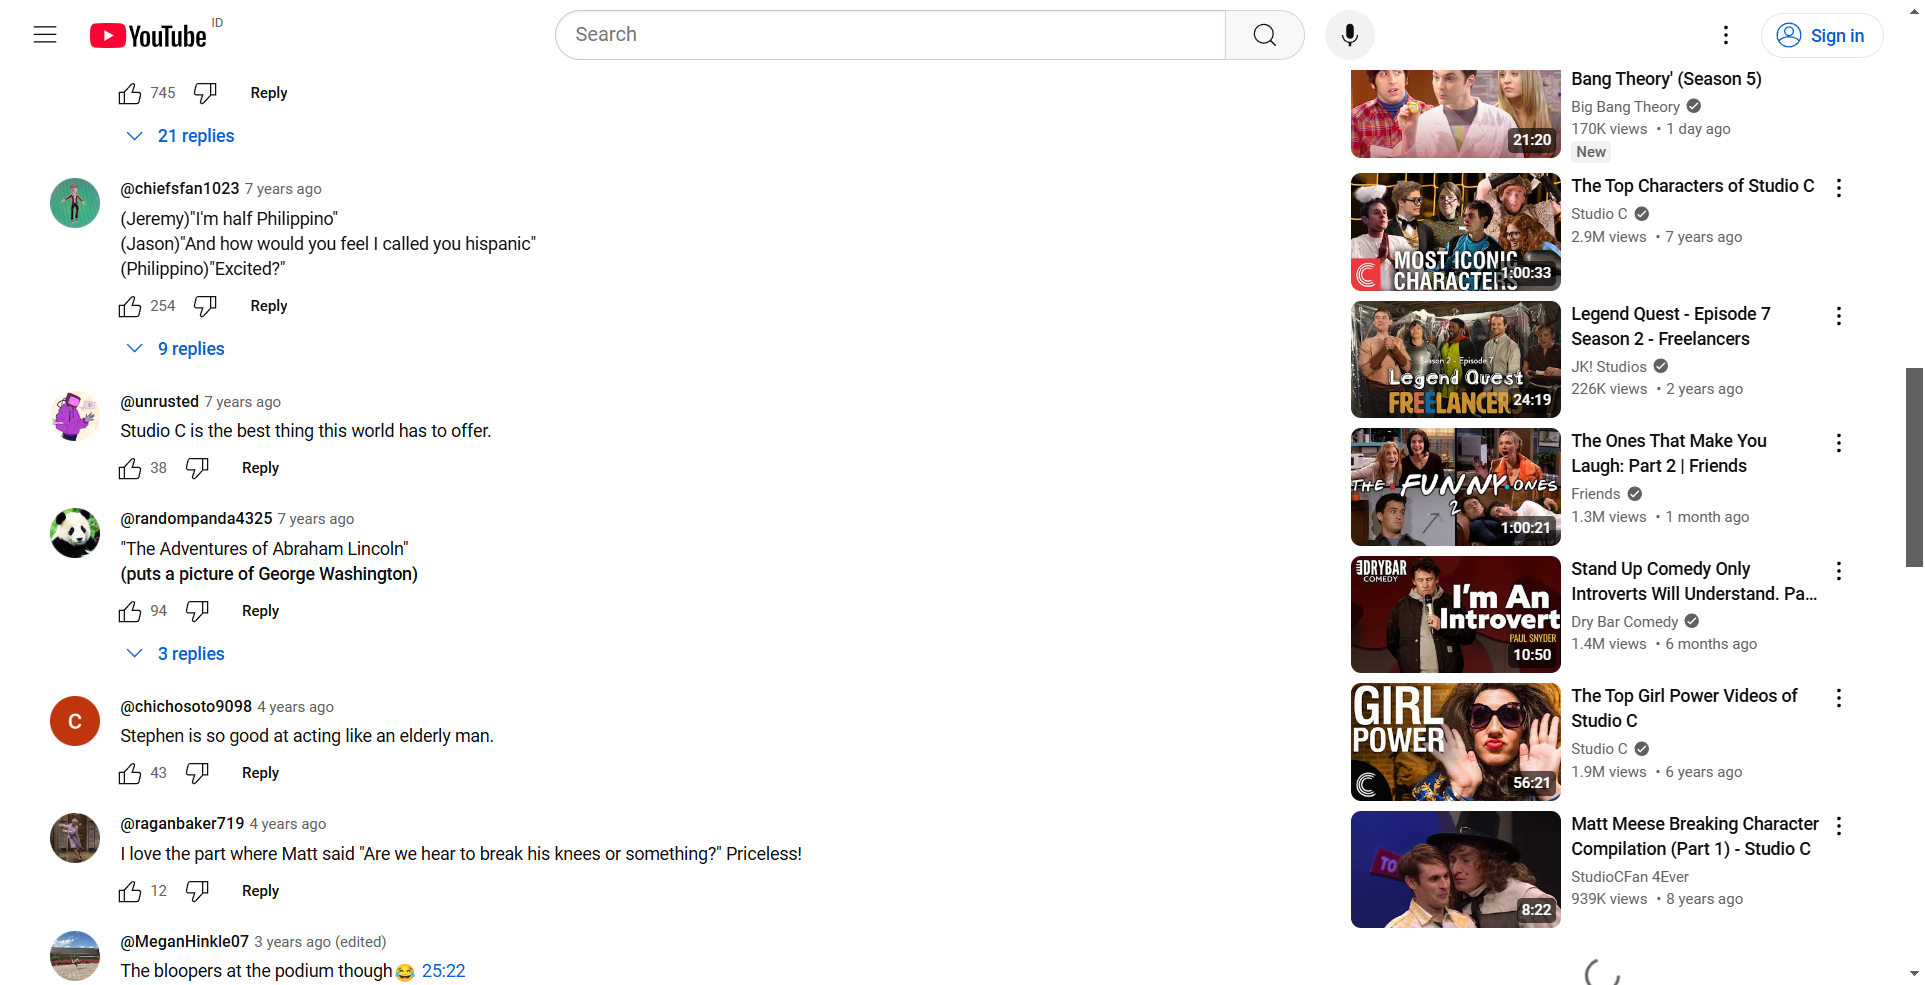

In [22]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
import undetected_chromedriver as uc
from IPython.display import display, Image

# Start undetected Chrome (no login required for YouTube)
options = webdriver.ChromeOptions()
options.add_argument("--disable-blink-features=AutomationControlled")  # Helps avoid detection
driver = uc.Chrome(options=options, headless=False)

# Open YouTube video page
video_url = "VIDEO URL"  # Replace with your desired video URL
driver.get(video_url)

# Wait for the comments section to load
WebDriverWait(driver, 10).until(
    EC.presence_of_element_located((By.CSS_SELECTOR, "#comments"))
)

search_name = "TARGET NAME"  # Target username or text to search for
found = False

# Function to extract comment texts using JavaScript
def get_comments_via_js(driver):
    script = """
    let commentElements = document.querySelectorAll('#content-text');
    let result = [];
    commentElements.forEach(comment => result.push(comment.innerText));
    return result;
    """
    return driver.execute_script(script)

# Function to extract usernames using JavaScript
def get_usernames_via_js(driver):
    script = """
    let usernameElements = document.querySelectorAll('#author-text span');
    let result = [];
    usernameElements.forEach(user => result.push(user.innerText));
    return result;
    """
    return driver.execute_script(script)

# Infinite scrolling loop to load comments and check for the target name
while not found:
    # Scroll down a page
    driver.find_element(By.TAG_NAME, "body").send_keys(Keys.PAGE_DOWN)
    WebDriverWait(driver, 2).until(
        EC.presence_of_element_located((By.CSS_SELECTOR, "#comments"))
    )
    
    # Extract the current list of usernames and comment texts
    usernames = get_usernames_via_js(driver)
    comments = get_comments_via_js(driver)
    
    # Debug: print out all usernames and comment texts
    for user, comment in zip(usernames, comments):
        print(f"User: {user} | Comment: {comment}")
        if search_name.lower() in user.lower() or search_name.lower() in comment.lower():
            print(f"\n✅ Found '{search_name}'! Taking screenshot...\n")
            found = True
            break

    # If found, exit loop, else keep scrolling
    if found:
        break

# Take screenshot and quit
screenshot_path = "youtube_screenshot.png"
driver.save_screenshot(screenshot_path)
driver.quit()

# Display screenshot in the notebook
display(Image(filename=screenshot_path))


🔍 Highlighted: TikTok
🔍 Highlighted: Search
🔍 Highlighted: For You
🔍 Highlighted: Explore
🔍 Highlighted: Following
🔍 Highlighted: Upload
🔍 Highlighted: LIVE
🔍 Highlighted: Profile
🔍 Highlighted: More
🔍 Highlighted: Log in
🔍 Highlighted: 
🔍 Highlighted: 2M
🔍 Highlighted: 7459
🔍 Highlighted: 52.4K
🔍 Highlighted: 21.8K
🔍 Highlighted: 
🔍 Highlighted: rafaiueo
RafaW
·
1w ago
🔍 Highlighted: Follow
🔍 Highlighted: suara asli - RafaW
🔍 Highlighted: 
🔍 Highlighted: senjaRaza
🔍 Highlighted: 129.9K
🔍 Highlighted: Reply
🔍 Highlighted: 
🔍 Highlighted: may
🔍 Highlighted: 78.5K
🔍 Highlighted: Reply
🔍 Highlighted: 
🔍 Highlighted: Gktausp💥🤙🏻
🔍 Highlighted: 11
🔍 Highlighted: Reply
🔍 Highlighted: 
🔍 Highlighted: ...
🔍 Highlighted: 2093
🔍 Highlighted: Reply
🔍 Highlighted: 
🔍 Highlighted: ieuvidio.in
🔍 Highlighted: 7251
🔍 Highlighted: Reply
🔍 Highlighted: 
🔍 Highlighted: n.noviii
🔍 Highlighted: 35
🔍 Highlighted: Reply
🔍 Highlighted: 
🔍 Highlighted: jelly•⩊•
🔍 Highlighted: 44.1K
🔍 Highlighted: Reply
🔍 Highli

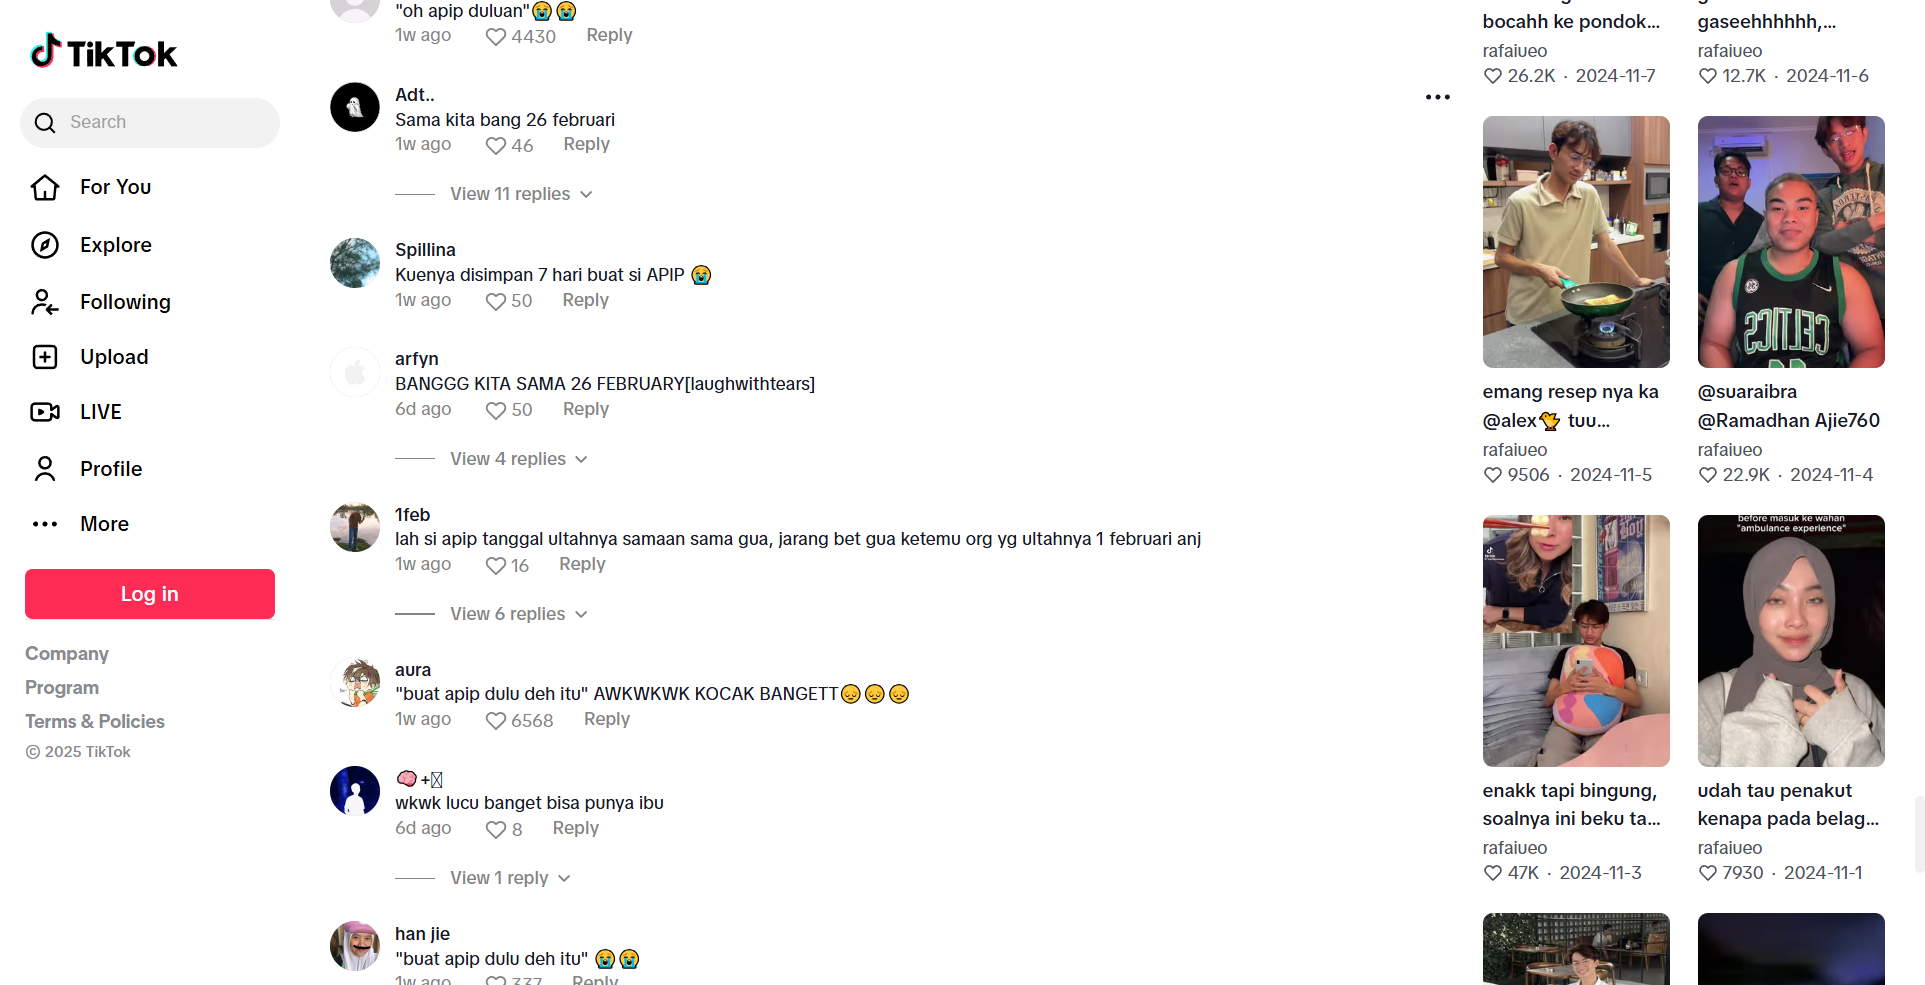

In [28]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
import undetected_chromedriver as uc
from IPython.display import display, Image
import time

# Start undetected Chrome
options = webdriver.ChromeOptions()
options.add_argument("--disable-blink-features=AutomationControlled")
driver = uc.Chrome(options=options, headless=False)

# Open TikTok video page
video_url = "INPUT URL"
driver.get(video_url)
time.sleep(5)

search_name = "Target username"
found = False

# Function to get the currently focused element
def get_focused_element():
    return driver.execute_script("return document.activeElement;")

tab_count = 0
safety_limit = 500  # Prevent infinite loops

while not found and tab_count < safety_limit:
    driver.find_element(By.TAG_NAME, "body").send_keys(Keys.TAB)
    time.sleep(0.1)
    tab_count += 1

    focused_element = get_focused_element()
    if focused_element:
        highlighted_text = focused_element.text.strip()
        print(f"🔍 Highlighted: {highlighted_text}")
        if search_name == highlighted_text:
            print(f"\n✅ Found '{search_name}'! Taking screenshot...\n")
            found = True
            break

if tab_count >= safety_limit:
    print("⚠️ Safety limit reached. Username may not have been found.")

# Take screenshot and quit
screenshot_path = "tiktok_screenshot.png"
driver.save_screenshot(screenshot_path)
driver.quit()

# Display screenshot in the notebook
display(Image(filename=screenshot_path))


✅ Login successful!
🔍 Highlighted: Find friends
Number of unread notifications
1
Video
More
Home
Live
Reels
Shows
Explore
Saved videos
Following
0:03 / 18:39
Kawanan Cop3t Terminal Kampung Rambutan - TL Pasar Rebo Kami Cyduk
Like
Comment
Share
181K
  ·
10.3K comments
  ·
17M views
Tim Raimas
e
r
S
o
p
n
o
d
s
t
l
b
f
6
i
c
3
2
l
t
 2
r
2
9
1
0
5
5
5
a
m
l
i
h
l
m
u
 9
1
i
c
t
O
t
7
l
4
u
6
o
c
1
4
0
1
4
e
9
  ·
Follow
Overview
Comments
Kawanan Cop3t Terminal Kampung Rambutan - TL Pasar Rebo Kami Cyduk
Comments
Most relevant
Ganden Ajibarang
Kalo polisi seperti pak ambarita semua mungkin indoneaia indah suasana semoga polisi yg lain bsa seperti pak ambarita
8w
Like
Reply
See translation
1.3K
View all 242 replies
Aza Wa Jalla
Sangat lah jarang polisi seperti pak Ambarita,,, jika lah ada hanya beberapa persen saja jiga polisi nya seperti pak Ambarita semua tentu Indonesia sangatlah damai dan tentram,, Buat pak Ambarita semoga selalu sehat panjang umur dan senantiasa dalam li… See more
7w


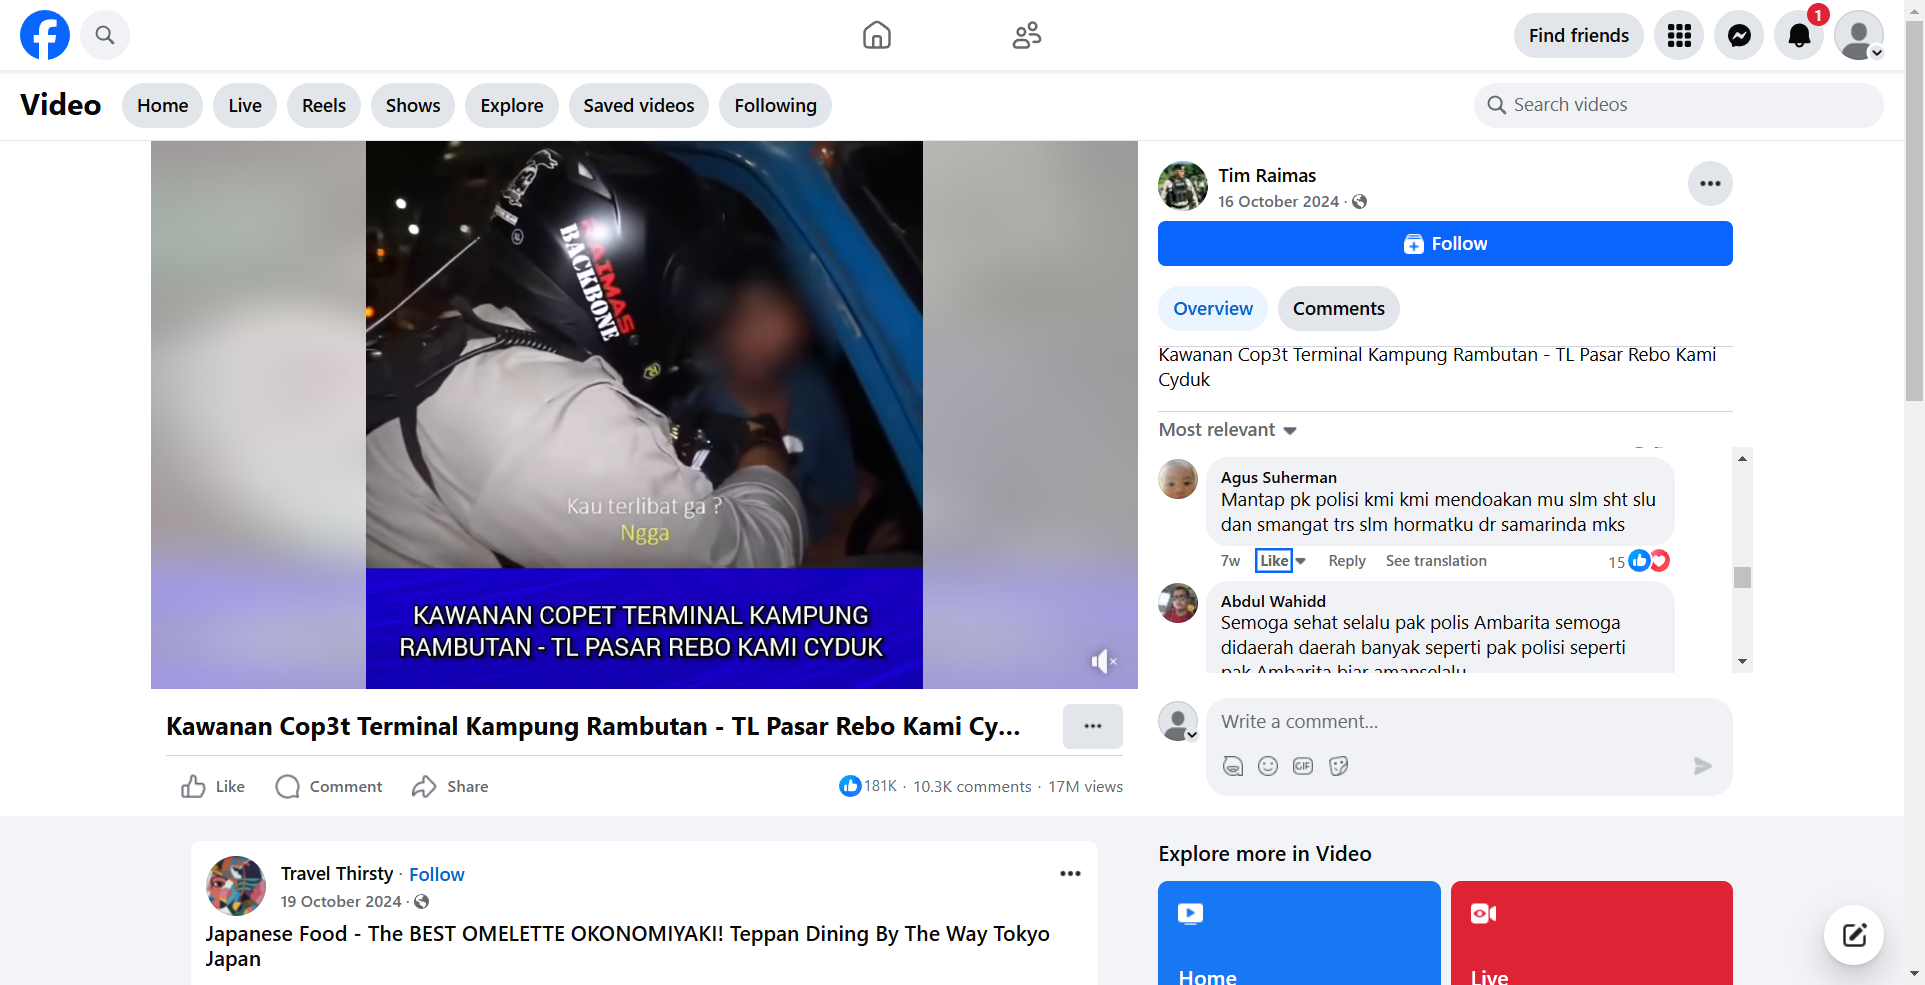

In [32]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
import undetected_chromedriver as uc
from IPython.display import display, Image
import time

# Facebook login credentials
FB_EMAIL = "EMAIL"
FB_PASSWORD = "PASSWORD."

# Start undetected Chrome
options = webdriver.ChromeOptions()
options.add_argument("--disable-blink-features=AutomationControlled")  # Helps avoid detection
driver = uc.Chrome(options=options, headless=False)

# Open Facebook login page
driver.get("https://www.facebook.com/")
time.sleep(5)  # Allow time for page to load

# Perform login
try:
    wait = WebDriverWait(driver, 10)
    email_input = wait.until(EC.presence_of_element_located((By.ID, "email")))
    email_input.send_keys(FB_EMAIL)
    
    password_input = driver.find_element(By.ID, "pass")
    password_input.send_keys(FB_PASSWORD)
    password_input.send_keys(Keys.ENTER)
    
    time.sleep(5)
    print("✅ Login successful!")
except Exception as e:
    print(f"❌ Login failed: {e}")

# Open Facebook post page
post_url = "URL"
driver.get(post_url)
time.sleep(5)

search_name = "TARGETED USERNAME"
found = False

# Function to get the currently focused element
def get_focused_element():
    return driver.execute_script("return document.activeElement;")

tab_count = 0
safety_limit = 500

while not found and tab_count < safety_limit:
    driver.find_element(By.TAG_NAME, "body").send_keys(Keys.TAB)
    time.sleep(0.1)
    tab_count += 1

    focused_element = get_focused_element()
    if focused_element:
        highlighted_text = focused_element.text.strip()
        print(f"🔍 Highlighted: {highlighted_text}")
        
        if "View more comments" in highlighted_text:
            focused_element.send_keys(Keys.ENTER)
            time.sleep(2)
            continue
        
        if search_name == highlighted_text:
            print(f"\n✅ Found '{search_name}'! Pressing Tab 3 more times before screenshot...\n")
            for _ in range(3):
                driver.find_element(By.TAG_NAME, "body").send_keys(Keys.TAB)
                time.sleep(0.1)
            found = True
            break

if tab_count >= safety_limit:
    print("⚠️ Safety limit reached. Username may not have been found.")

# Take screenshot and quit
screenshot_path = "facebook_screenshot.png"
driver.save_screenshot(screenshot_path)
driver.quit()

# Display screenshot in the notebook
display(Image(filename=screenshot_path))
